# **Import Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Load Dataset**

In [3]:
df = pd.read_csv("energy_efficiency_data.csv")
df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


## **Rename Columns**

In [4]:
df.columns = [
'Relative_Compactness','Surface_Area','Wall_Area',
'Roof_Area','Overall_Height','Orientation',
'Glazing_Area','Glazing_Distribution',
'Heating_Load','Cooling_Load'
]

# **Dataset Understanding / Verification**

In [5]:
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Relative_Compactness  768 non-null    float64
 1   Surface_Area          768 non-null    float64
 2   Wall_Area             768 non-null    float64
 3   Roof_Area             768 non-null    float64
 4   Overall_Height        768 non-null    float64
 5   Orientation           768 non-null    int64  
 6   Glazing_Area          768 non-null    float64
 7   Glazing_Distribution  768 non-null    int64  
 8   Heating_Load          768 non-null    float64
 9   Cooling_Load          768 non-null    float64
dtypes: float64(8), int64(2)
memory usage: 60.1 KB


,0
Relative_Compactness,0
Surface_Area,0
Wall_Area,0
Roof_Area,0
Overall_Height,0
Orientation,0
Glazing_Area,0
Glazing_Distribution,0
Heating_Load,0
Cooling_Load,0


# **Data Cleaning & Verification**

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

print("Dataset Shape:", df.shape)

Duplicate Rows: 0
Dataset Shape: (768, 10)


# **Exploratory Analysis**

### **Heating Load Distribution**

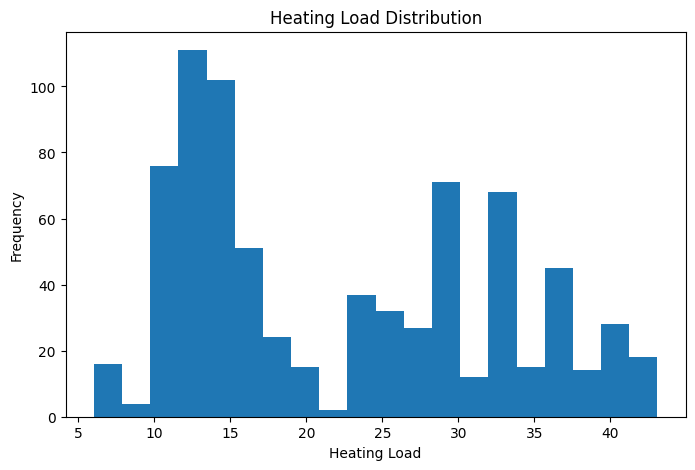

In [7]:
plt.figure(figsize=(8,5))
plt.hist(df['Heating_Load'], bins=20)
plt.title("Heating Load Distribution")
plt.xlabel("Heating Load")
plt.ylabel("Frequency")
plt.show()

### **Cooling Load Distribution**

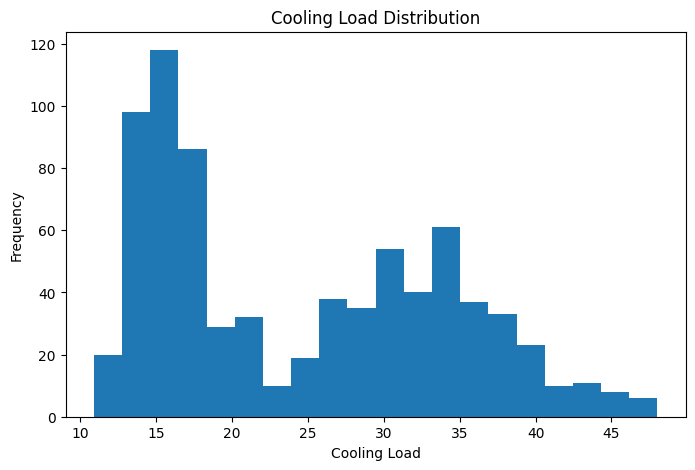

In [8]:
plt.figure(figsize=(8,5))
plt.hist(df['Cooling_Load'], bins=20)
plt.title("Cooling Load Distribution")
plt.xlabel("Cooling Load")
plt.ylabel("Frequency")
plt.show()

### **Correlation Heatmap**

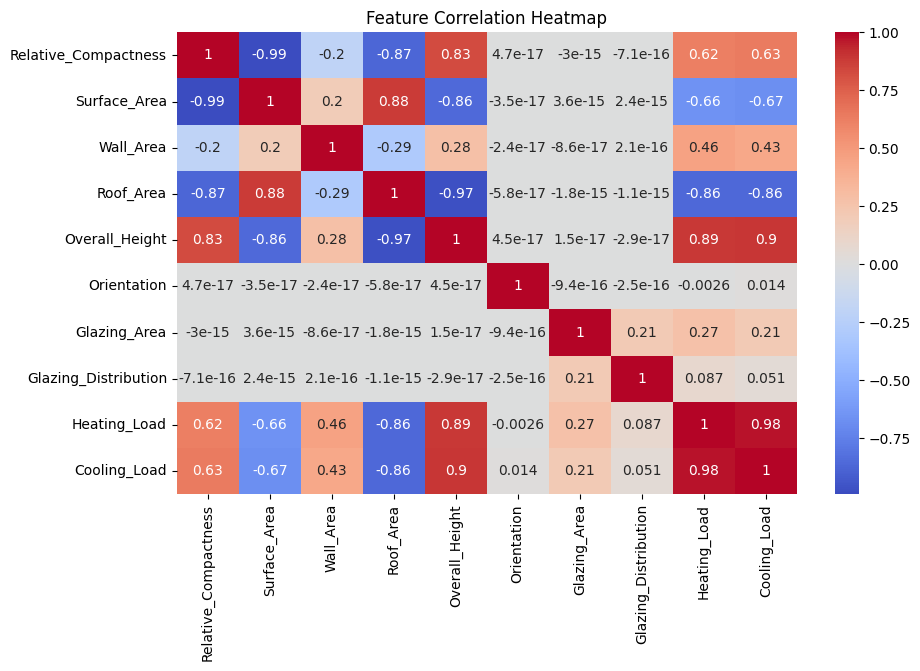

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

### **Heating vs Cooling Scatter Plot**

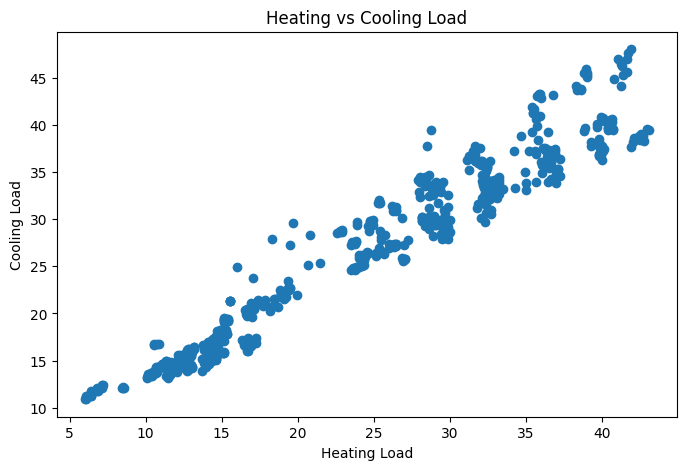

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(df['Heating_Load'], df['Cooling_Load'])
plt.xlabel("Heating Load")
plt.ylabel("Cooling Load")
plt.title("Heating vs Cooling Load")
plt.show()

### **Average Comparison Bar Chart(Calculate Metrics)**

22.307200520833334
24.58776041666667


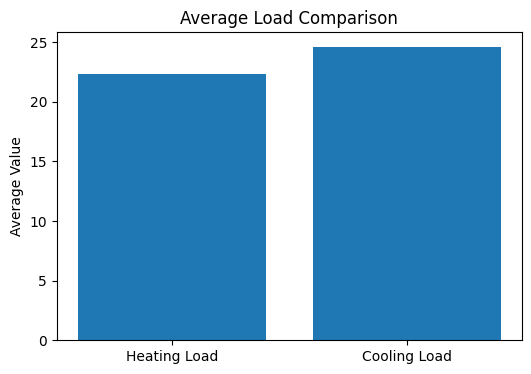

In [11]:
avg_heat = df['Heating_Load'].mean()
avg_cool = df['Cooling_Load'].mean()

print(avg_heat)
print(avg_cool)


plt.figure(figsize=(6,4))
plt.bar(['Heating Load','Cooling Load'],
        [avg_heat, avg_cool])

plt.title("Average Load Comparison")
plt.ylabel("Average Value")
plt.show()

### **Boxplot**

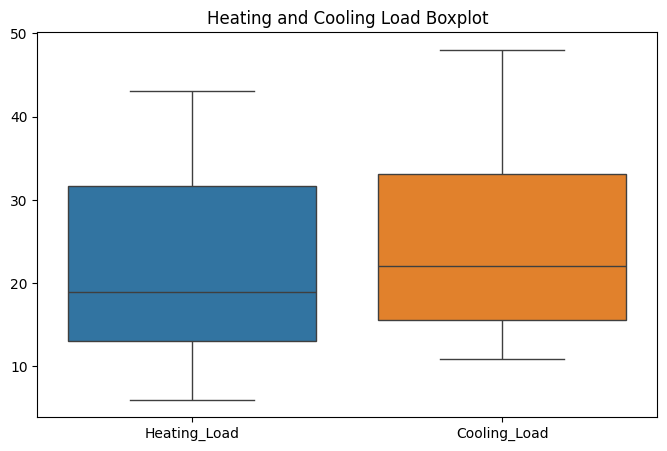

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df[['Heating_Load','Cooling_Load']])
plt.title("Heating and Cooling Load Boxplot")
plt.show()

# **Feature Engineering**

In [13]:
df['Energy_Efficiency_Score'] = (
    df['Heating_Load'] + df['Cooling_Load']
)/2

df.head()

,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Distribution,Heating_Load,Cooling_Load,Energy_Efficiency_Score
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33,18.44
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33,18.44
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33,18.44
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33,18.44
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28,24.56


# **Machine Learning Models**

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

X = df.drop(
    ['Heating_Load', 'Cooling_Load'],
    axis=1
)

y = df['Heating_Load']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (614, 9)
Testing Shape: (154, 9)


## **Random Forest Model**

In [15]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest Model Trained")

Random Forest Model Trained


## **XGBoost Model**

In [16]:
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

print("XGBoost Model Trained")

XGBoost Model Trained


## **Model Evaluation**

In [17]:
def evaluate_model(y_true, y_pred, name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = mean_squared_error(
        y_true,
        y_pred
    ) ** 0.5

    r2 = r2_score(
        y_true,
        y_pred
    )

    print("="*50)
    print(name)
    print("="*50)

    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R²  :", round(r2,2))


evaluate_model(
    y_test,
    rf_pred,
    "Random Forest"
)

evaluate_model(
    y_test,
    xgb_pred,
    "XGBoost"
)

Random Forest
MAE : 0.35
RMSE: 0.66
R²  : 1.0
XGBoost
MAE : 0.3
RMSE: 0.5
R²  : 1.0


## **Residual Plot**

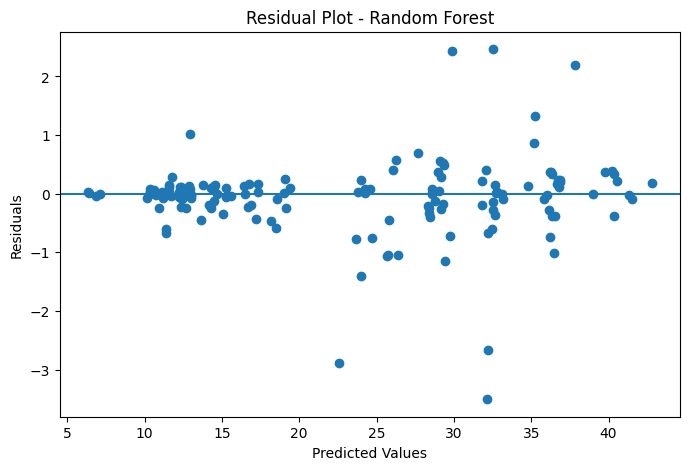

In [18]:
residuals = y_test - rf_pred

plt.figure(figsize=(8,5))

plt.scatter(
    rf_pred,
    residuals
)

plt.axhline(0)

plt.title(
    "Residual Plot - Random Forest"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.show()

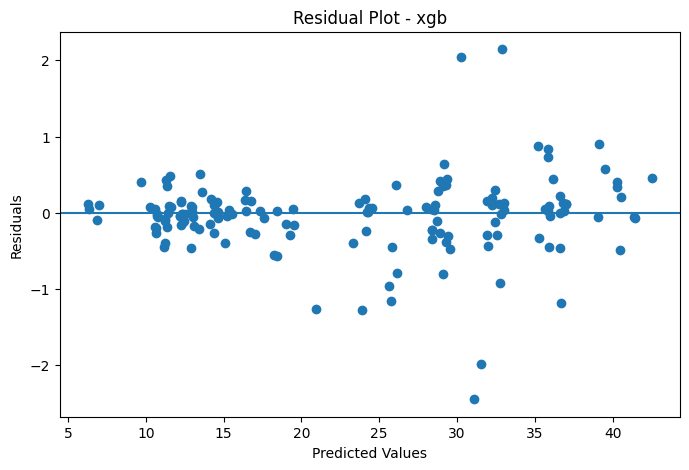

In [19]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,5))

plt.scatter(
    xgb_pred,
    residuals
)

plt.axhline(0)

plt.title(
    "Residual Plot - xgb"
)

plt.xlabel(
    "Predicted Values"
)

plt.ylabel(
    "Residuals"
)

plt.show()

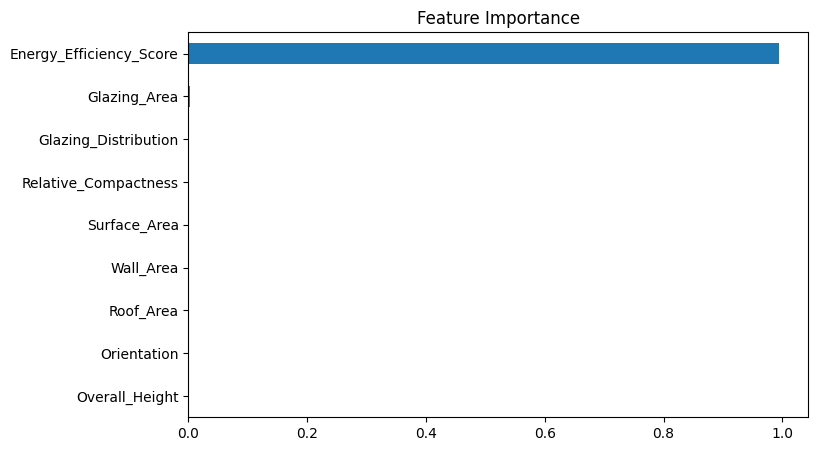

In [20]:
importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(
    kind='barh',
    figsize=(8,5)
)

plt.title(
    "Feature Importance"
)

plt.show()

## **Save Model (.pkl)**

In [21]:
import joblib

joblib.dump(
    rf_model,
    "random_forest_model.pkl"
)

print(
    "Random Forest Model Saved"
)

Random Forest Model Saved


In [22]:
df.to_parquet(
    "building_energy_data.parquet"
)

print(
    "Dataset Saved as Parquet"
)

Dataset Saved as Parquet


# **Verification Testing**

In [23]:
print("Verification Testing")

print("Rows:", len(df))
print("Columns:", len(df.columns))

if len(df) > 0:
    print("CSV/Data Load Test: PASSED")
else:
    print("CSV/Data Load Test: FAILED")

Verification Testing
Rows: 768
Columns: 11
CSV/Data Load Test: PASSED


# **Recommendation Logic**

In [24]:
avg_heat = df[
    'Heating_Load'
].mean()

avg_cool = df[
    'Cooling_Load'
].mean()

if avg_heat > 30:

    recommendation = (
        "Reduce HVAC runtime by 10%"
    )

elif avg_heat > 20:

    recommendation = (
        "Monitor HVAC usage regularly"
    )

else:

    recommendation = (
        "Building energy usage is efficient"
    )

print(recommendation)

Monitor HVAC usage regularly


# **Chatbot Interface**

In [25]:
print("="*50)
print(
    "AI Sustainability Chatbot"
)
print("="*50)

while True:

    query = input(
        "Ask heating/cooling/save or exit: "
    ).lower()

    if query == "exit":

        print(
            "Chatbot Closed"
        )

        break

    elif "heating" in query:

        print(
            "Average Heating Load:",
            round(avg_heat,2)
        )

    elif "cooling" in query:

        print(
            "Average Cooling Load:",
            round(avg_cool,2)
        )

    elif "save" in query:

        print(
            "Suggestion: Reduce HVAC runtime and improve insulation."
        )

    else:

        print(
            "Sorry, I did not understand."
        )

AI Sustainability Chatbot
Ask heating/cooling/save or exit: heating
Average Heating Load: 22.31
Ask heating/cooling/save or exit: cooling
Average Cooling Load: 24.59
Ask heating/cooling/save or exit: save
Suggestion: Reduce HVAC runtime and improve insulation.
Ask heating/cooling/save or exit: exit
Chatbot Closed


## **Dashboard Style Output**

In [26]:
print("="*50)
print(
    "BUILDING ENERGY REPORT"
)
print("="*50)

print(
    "Average Heating Load:",
    round(avg_heat,2)
)

print(
    "Average Cooling Load:",
    round(avg_cool,2)
)

print(
    "Recommendation:",
    recommendation
)

print("="*50)

BUILDING ENERGY REPORT
Average Heating Load: 22.31
Average Cooling Load: 24.59
Recommendation: Monitor HVAC usage regularly


### **Plotly Dashboard Graph**

In [27]:
import plotly.express as px

fig = px.scatter(
    df,
    x='Heating_Load',
    y='Cooling_Load',
    title='Heating vs Cooling Dashboard'
)

fig.show()

# **Validation / Feedback Dataset**

In [28]:
feedback = {
'User':['Manager','Student','Staff'],
'Ease_of_Use_Score':[9,8,9],
'Useful_Score':[8,9,8]
}

In [29]:
feedback_df = pd.DataFrame(feedback)
avg_use = feedback_df['Ease_of_Use_Score'].mean()
avg_help = feedback_df['Useful_Score'].mean()

print("Average Ease of Use:",
      round(avg_use,2))

print("Average Usefulness:",
      round(avg_help,2))

if avg_use >= 8 and avg_help >= 8:
    print("Validation Status: PASSED")
else:
    print("Validation Status: NEEDS IMPROVEMENT")

Average Ease of Use: 8.67
Average Usefulness: 8.33
Validation Status: PASSED
